Forma dei dati (campioni, feature): (1797, 64)
Numero di classi (cifre 0-9): 10
Esempio di vettore feature (prima immagine, 64 valori):
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]

Forma dei dati dopo la riduzione con t-SNE: (1797, 2)
Prime 5 coordinate 2D calcolate:
[[-38.777     -30.429148 ]
 [-15.336499   -2.7883544]
 [  5.937756  -14.502025 ]
 [ 28.00608     2.9412334]
 [-36.394794    2.6174462]]


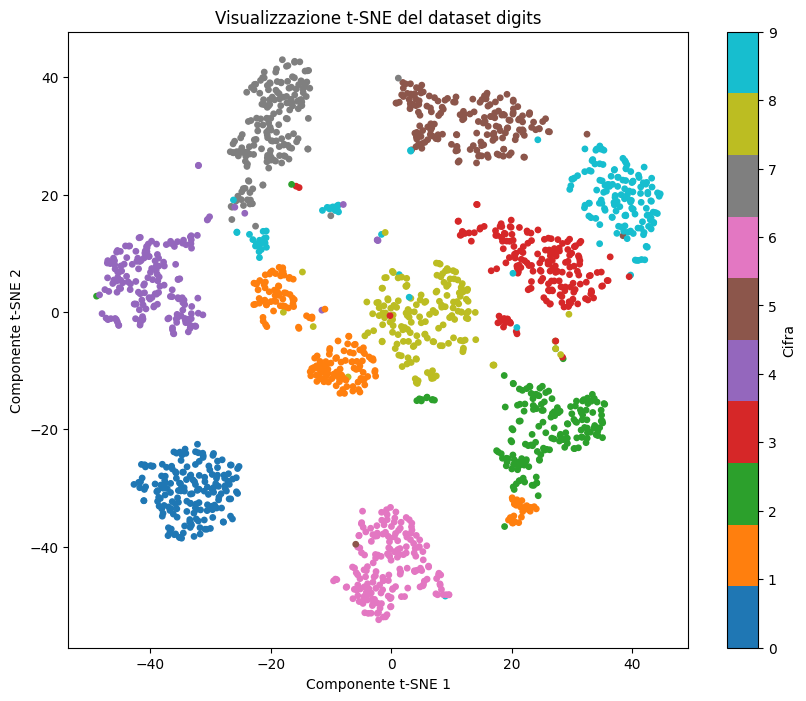

In [1]:
# =============================================================
# Riduzione della dimensionalità con t-SNE
# =============================================================

# Importazione delle librerie e caricamento del dataset
# Importiamo le librerie necessarie per il preprocessing, il modello
# t-SNE e la visualizzazione dei risultati
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# Carichiamo il dataset digits: 1797 immagini 8x8 di cifre scritte
# a mano (da 0 a 9), gia trasformate in vettori di 64 feature (pixel)
digits = load_digits()
X = digits.data      # matrice delle feature: 1797 campioni x 64 feature
y = digits.target    # etichette delle cifre (0-9), usate solo per colorare il grafico


# Esplorazione della struttura del dataset
# Verifichiamo le dimensioni del dataset originale, per capire
# perche una visualizzazione diretta non e possibile
print("Forma dei dati (campioni, feature):", X.shape)
print("Numero di classi (cifre 0-9):", len(np.unique(y)))
print("Esempio di vettore feature (prima immagine, 64 valori):")
print(X[0])


# Standardizzazione delle feature
# Portiamo tutte le feature sulla stessa scala, poiche t-SNE si basa
# su distanze tra punti ed e sensibile a differenze di scala tra le feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Configurazione dell'algoritmo t-SNE
# Impostiamo il modello t-SNE per ridurre le 64 dimensioni originali
# a sole 2 dimensioni, adatte alla visualizzazione su un grafico 2D
tsne = TSNE(
    n_components=2,     # numero di dimensioni di output desiderate
    perplexity=30,       # bilancia l'attenzione tra struttura locale e globale
    max_iter=1000,        # numero massimo di iterazioni di ottimizzazione
                            # (nelle versioni di scikit-learn precedenti alla 1.5
                            # questo parametro si chiamava n_iter)
    random_state=42        # garantisce la riproducibilita dei risultati
)


# Trasformazione dei dati in due dimensioni
# Applichiamo fit_transform per calcolare le nuove coordinate 2D
# Nota: t-SNE non dispone di un metodo transform separato, quindi
# non puo essere riutilizzato su nuovi dati non visti in fase di addestramento
X_tsne = tsne.fit_transform(X_scaled)

print("\nForma dei dati dopo la riduzione con t-SNE:", X_tsne.shape)
print("Prime 5 coordinate 2D calcolate:")
print(X_tsne[:5])


# Visualizzazione del risultato
# Creiamo uno scatter plot colorato in base alla cifra rappresentata,
# per verificare visivamente se t-SNE ha separato correttamente i gruppi
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=15)
plt.colorbar(scatter, label="Cifra")
plt.title("Visualizzazione t-SNE del dataset digits")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.show()
